# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', None)
sns.color_palette("Set2")
sns.set_palette('colorblind')

# Load

In [2]:
df = pd.read_csv('../data/pc_cleaned.csv')
df.head(5)

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,price,country
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,No accident,Dealer,Excellent,EX,9,20433.666667,7208.52,Germany
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,6911.81,Japan
2,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,No accident,Private,Good,Base,9,13209.888889,25984.79,USA
3,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,8151.30,Japan
4,Mazda,Mazda3,2018,129770,160,Automatic,Diesel,FWD,Hatchback,White,Beige,1,No accident,Dealer,Good,EX,7,18538.571429,10822.61,Japan


# EDA

In [3]:
df.describe()

,year,mileage,engine_hp,owner_count,vehicle_age,mileage_per_year,price
count,215801.000000,215801.000000,215801.000000,215801.000000,215801.000000,215801.000000,215801.000000
mean,2017.436763,113021.995510,227.481295,3.489307,7.601179,14549.712683,19303.769721
std,3.852281,71597.091816,90.757676,1.537935,3.781883,6044.367715,12876.491325
min,2000.000000,500.000000,90.000000,1.000000,1.000000,38.461538,1500.000000
25%,2015.000000,58564.000000,157.000000,2.000000,5.000000,10534.857143,9941.180000
50%,2017.000000,103929.000000,205.000000,4.000000,8.000000,14711.333333,16999.710000
75%,2020.000000,158007.000000,289.000000,5.000000,10.000000,18696.833333,26163.010000
max,2025.000000,300000.000000,576.000000,5.000000,25.000000,34982.333333,90693.670000


In [4]:
df.shape

(215801, 20)

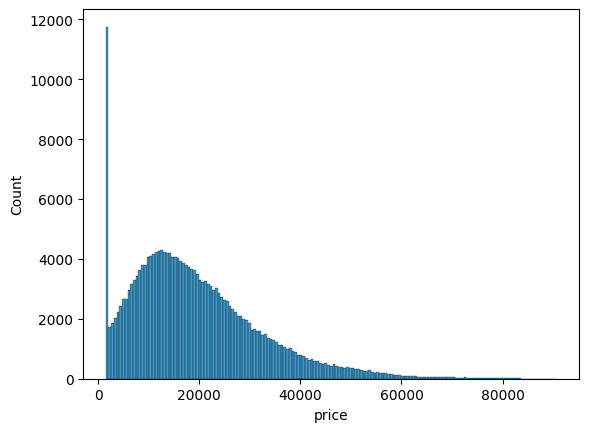

In [5]:
sns.histplot(df['price'])
plt.show()

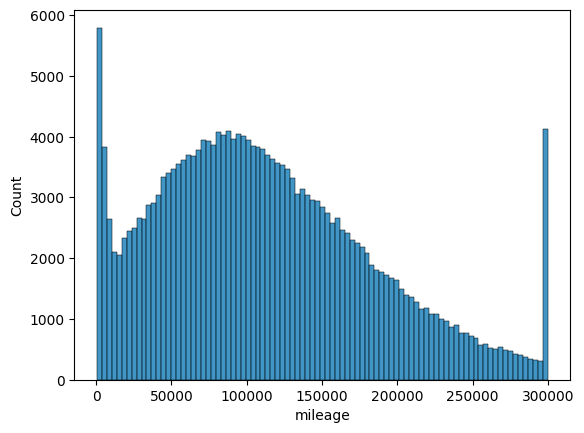

In [6]:
sns.histplot(df['mileage'])
plt.show()

In [7]:
limits = {'price_min':df[df['price']==1500].shape[0],
          'mileage_min':df[df['mileage']==500].shape[0],
          'mileage_max':df[df['mileage']==300000].shape[0]}
print(f'O dataset apresenta {limits['price_min']} valores mínimos($1500), representando {round(limits['price_min']*100/df.shape[0],2)}% da quantidade total de linhas.')
print(f'O dataset apresenta {limits['mileage_min']} valores mínimos(500), representando {round(limits['mileage_min']*100/df.shape[0],2)}% da quantidade total de linhas.')
print(f'O dataset apresenta {limits['mileage_max']} valores máximos(300000), representando {round(limits['mileage_max']*100/df.shape[0],2)}% da quantidade total de linhas.')


O dataset apresenta 10169 valores mínimos($1500), representando 4.71% da quantidade total de linhas.
O dataset apresenta 880 valores mínimos(500), representando 0.41% da quantidade total de linhas.
O dataset apresenta 3827 valores máximos(300000), representando 1.77% da quantidade total de linhas.


Mantê-los prejudica o modelo. As previsões de preços mais altos serão menores que o esperado, já que o modelo irá aprender o padrão do valor mínimo em uma escala muito maior que o restante, fazendo com que o algoritmo fique enviesado devido a alta frequência desses valores.

Outros valores que serão removidos serão 500 e 300000, pois eles são os limitadores, não possibilitando que valores menores que 500 ou maiores que 300000 sejam adicionados. Remover evita que carros que possuem 400k milhas seja computado como um carro de 300k milhas ou um carro que tenha 200 milhas conte como 500 milhas, garantindo que os valores não sejam mentirosos.

Lembrando que 500 e 300000 foram limites atribuídos apenas para este dataset em específico.

In [8]:
df = df[df['price']>1500]
df = df[(df['mileage']!=500) & (df['mileage']!=300000)]

<Axes: xlabel='mileage_per_year', ylabel='Count'>

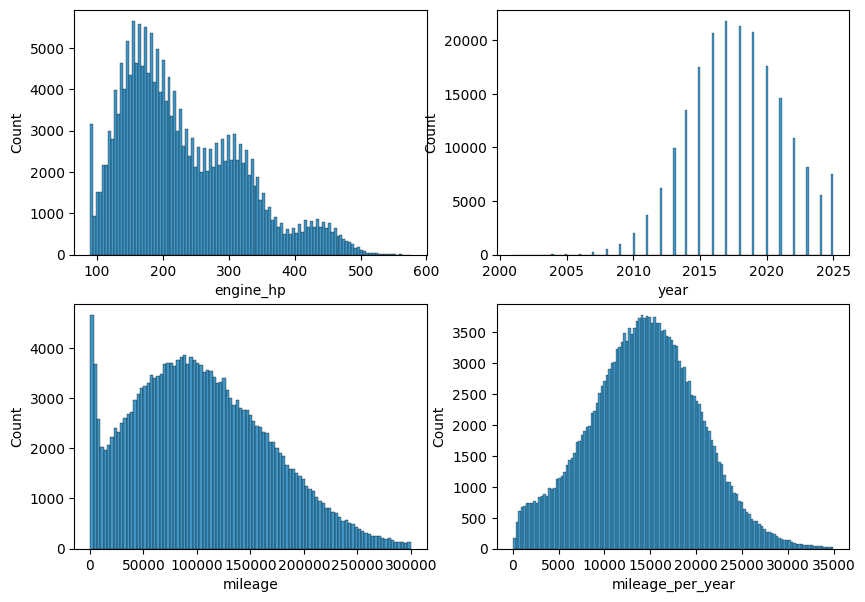

In [9]:
fig,ax = plt.subplots(2,2, figsize=(10,7))

sns.histplot(ax=ax[0,0],data=df,x='engine_hp')
sns.histplot(ax=ax[0,1],data=df,x='year')
sns.histplot(ax=ax[1,0],data=df,x='mileage')
sns.histplot(ax=ax[1,1],data=df,x='mileage_per_year')

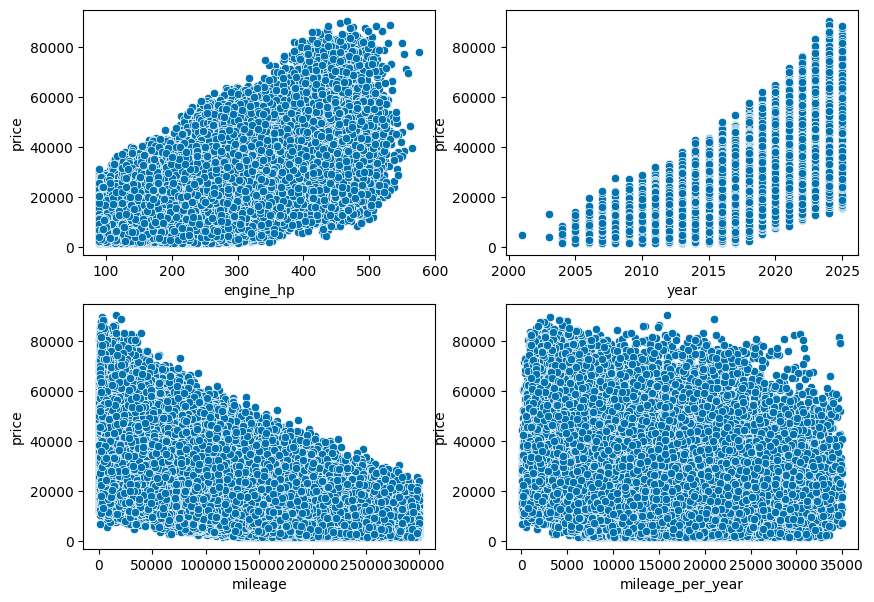

In [10]:
## Price per numerics
fig,ax = plt.subplots(2,2, figsize=(10,7))

sns.scatterplot(ax=ax[0,0],data=df,x='engine_hp', y='price')
sns.scatterplot(ax=ax[0,1],data=df,x='year', y='price')
sns.scatterplot(ax=ax[1,0],data=df,x='mileage', y='price')
sns.scatterplot(ax=ax[1,1],data=df,x='mileage_per_year', y='price')

plt.show()

É possível enxergar uma certa correlação entre price e engine_hp, year e mileage.

---

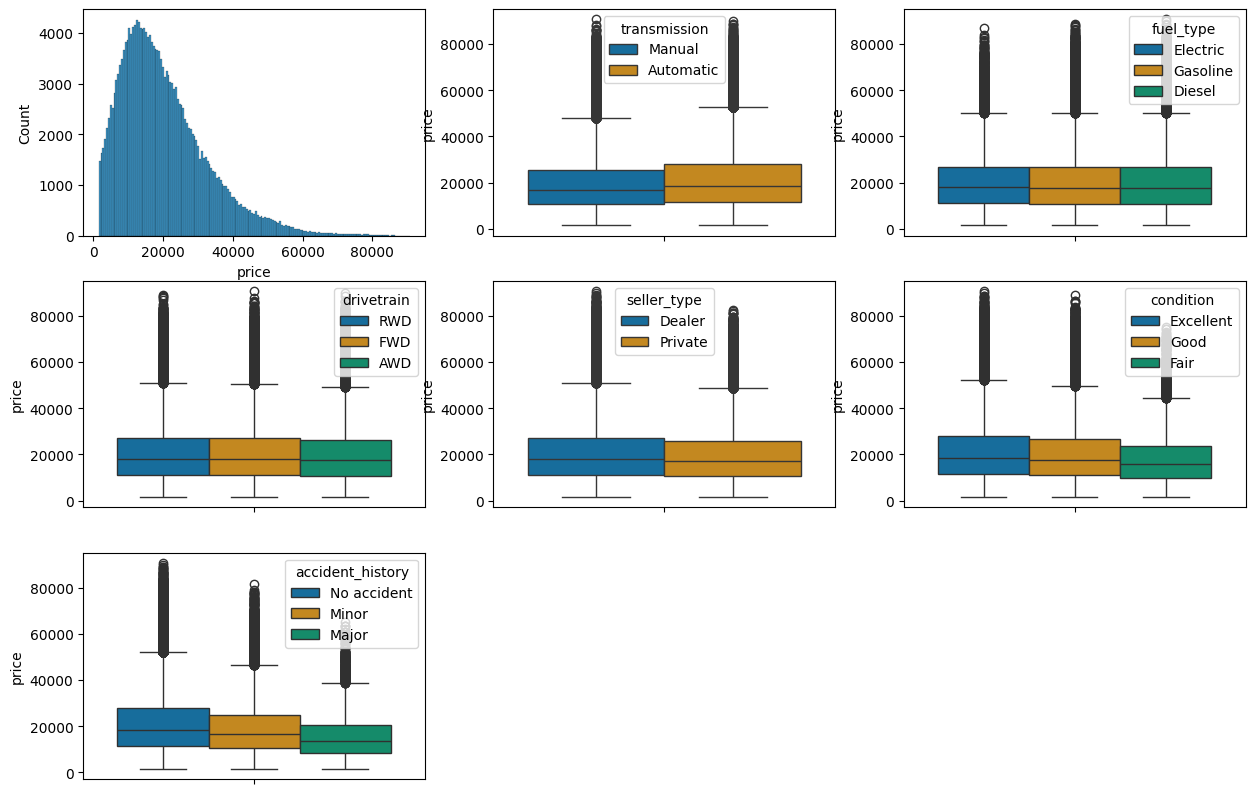

In [11]:
## 
fig,ax = plt.subplots(3,3, figsize=(15,10))

sns.histplot(ax=ax[0,0],data=df, x='price')
sns.boxplot(ax=ax[0,1], data=df, y='price', hue='transmission')
sns.move_legend(ax[0,1], 'upper center')
sns.boxplot(ax=ax[0,2], data=df, y='price', hue='fuel_type')
sns.move_legend(ax[0,2], 'upper right')
sns.boxplot(ax=ax[1,0], data=df, y='price', hue='drivetrain')
sns.move_legend(ax[1,0], 'upper right')
sns.boxplot(ax=ax[1,1], data=df, y='price', hue='seller_type')
sns.boxplot(ax=ax[1,2], data=df, y='price', hue='condition')
sns.move_legend(ax[1,2], 'upper right')
sns.boxplot(ax=ax[2,0], data=df, y='price', hue='accident_history')
sns.move_legend(ax[2,0], 'upper right')
ax[2,1].set_visible(False)
ax[2,2].set_visible(False)

plt.show()

1. No histograma de preço é possível observar a cauda para direita, indicando uma necessidade de aplicação do log.
2. Pelo fato dos dados serem sintéticos, é fácil notar o balanceamento.
3. As médias das classes não se distanciam muito.

---

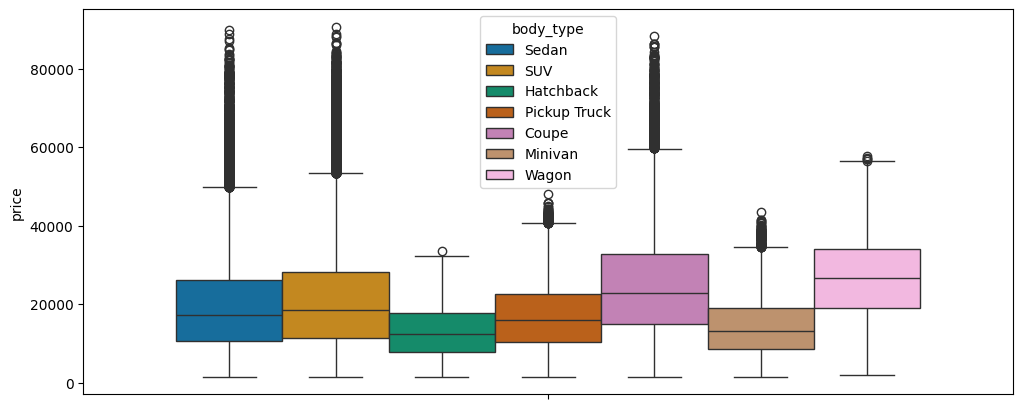

In [12]:
plt.figure(figsize=(12,5))
ax = sns.boxplot(data=df, y='price', hue='body_type')
plt.show()

In [13]:
df.groupby('body_type')['price'].mean()

body_type
Coupe           25228.345960
Hatchback       13118.173188
Minivan         14264.582904
Pickup Truck    16935.743410
SUV             21131.457017
Sedan           19749.050934
Wagon           26849.126690
Name: price, dtype: float64

Aqui há uma grande variedade nas médias, sendo carros coupes(~25k) e wagons(~27k) os tipos de modelos mais caros, e minivans(~14k) e hatchbacks(~13k) mais baratos, na média. 

---

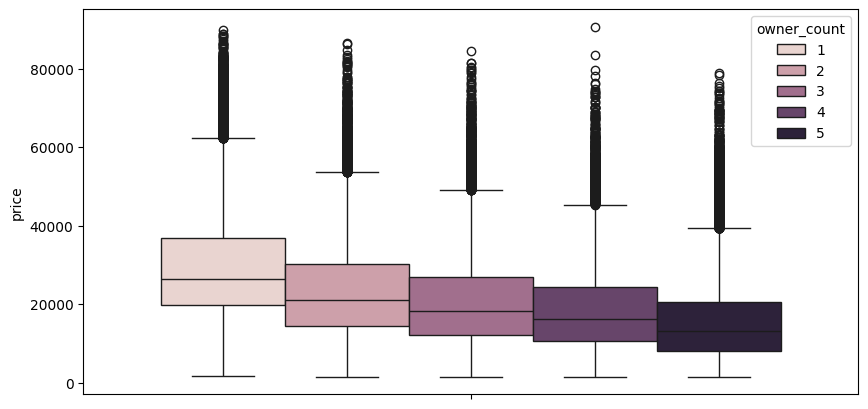

In [14]:
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, y='price', hue='owner_count')
plt.show()

É possível perceber que, quanto maior a quantidade de donos anteriores, menor o preço do carro.

---

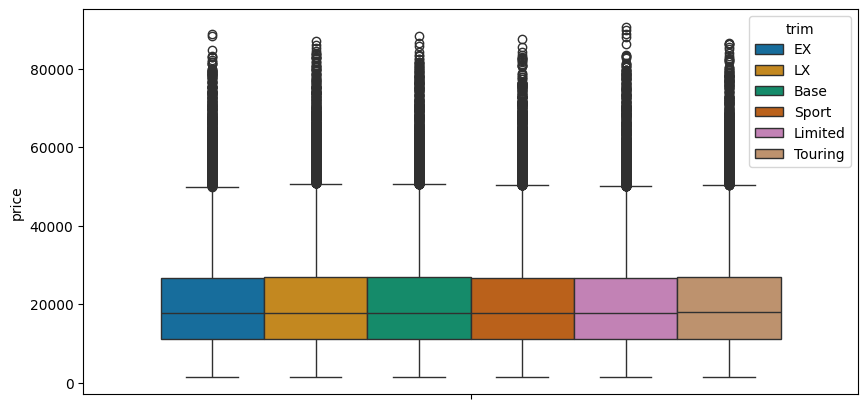

In [15]:
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, y='price', hue='trim')
plt.show()

A versão/acabamento dos modelos não influenciam muito no valor do carros.

Acredito que esse comportamento não se reflete na realidade. Normalmente um modelo Base teria uma diferença relevante comparado ao Touring.

---

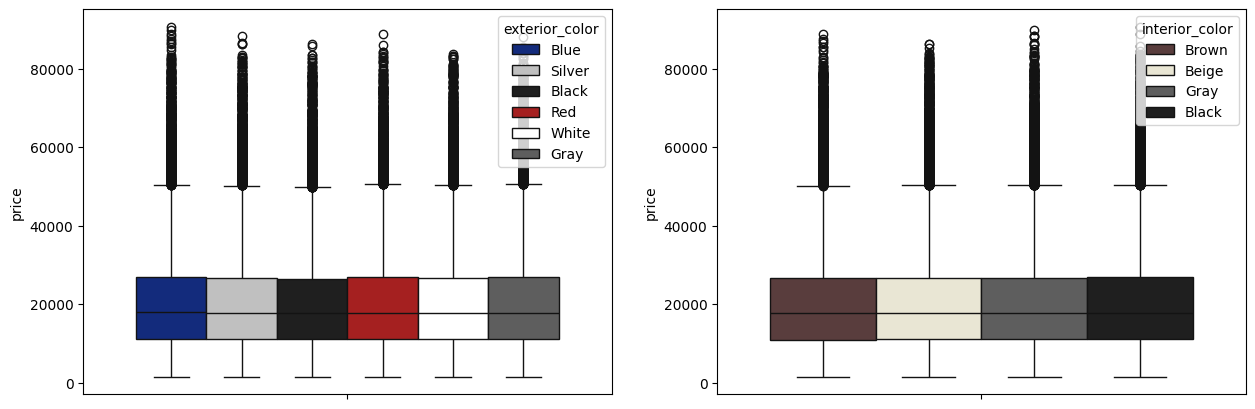

In [16]:
colors = {'Blue':'#01228E', 'Silver':'silver', 'Black':"#1F1F1F", 'Red':"#BB0A0A", 'White':'white', 'Gray':"#5E5E5E", 'Beige':'#EDE8D0', 'Brown':'#5E3838'}
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.boxplot(ax=ax[0], data=df, y='price', hue='exterior_color', palette=colors)
sns.move_legend(ax[0],'upper right')
sns.boxplot(ax=ax[1], data=df, y='price', hue='interior_color', palette=colors)
sns.move_legend(ax[1],'upper right')
plt.show()

Cores do interior ou exterior não alteram a média de valores de forma relevante.

---

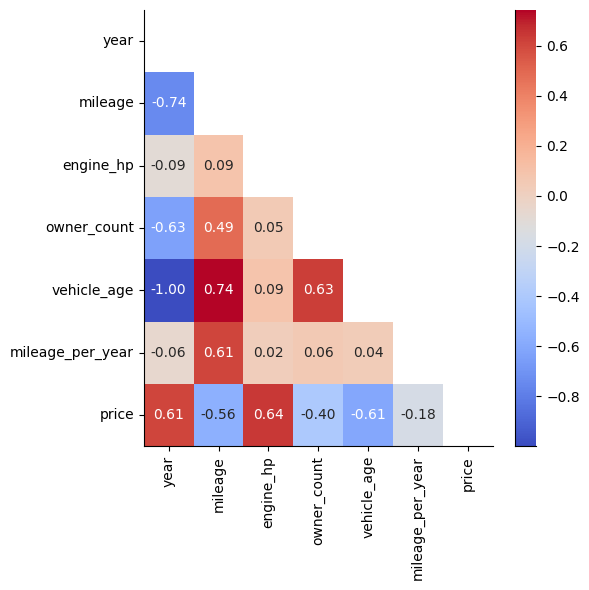

In [17]:
## heatmap
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))
fig, ax = plt.subplots(1,1, figsize=(6,6))
sns.heatmap(data=df.corr(numeric_only=True), 
            annot=True, 
            fmt='.2f', 
            mask=mask, 
            cmap='coolwarm')

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

A variável que parece ser menos relevante ao preço é a mileage_per_year, o resto apresenta bastante relevância.

As features 'year'e 'vehicle_age' dizem a mesma coisa.

---

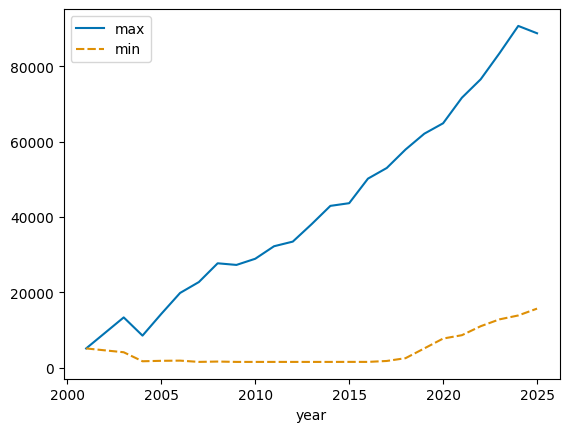

In [18]:
min_max = df.groupby('year')['price'].agg(['max','min'])
sns.lineplot(data=min_max)
plt.show()

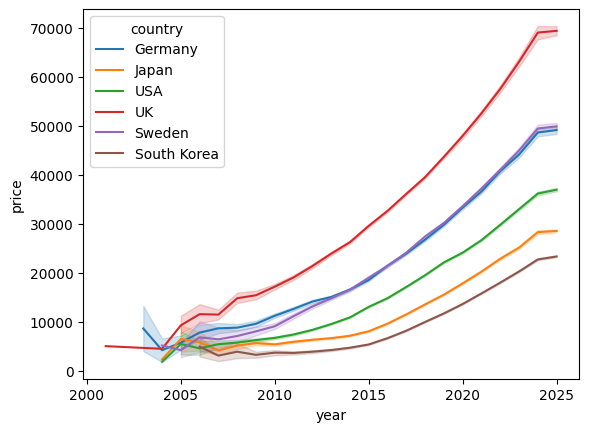

In [19]:
sns.lineplot(data=df,x='year',y='price',hue='country', palette='tab10')
plt.show()

As marcas do Reino Unido tendem a ter valores elevados em comparação ao resto e as marcas sul-coreanas têm os carros mais baratos.

---

In [20]:
## passando o dataset analisado e corrigido para csv
df.to_csv('../data/pc_cleaned.csv', index=False)
